# Customer Churn Prediction

# 3. Exploratory Data Analysis (EDA)

## Business Objective

The objective of Exploratory Data Analysis (EDA) is to understand customer behavior, identify factors influencing churn, and uncover meaningful business insights.

The insights obtained during this phase will guide feature engineering and machine learning model development.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/cleaned_telco_customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7032, 21)

## 3.1 Overall Churn Distribution

### Business Question

What percentage of customers have churned?

Understanding the overall churn rate provides a baseline for evaluating customer retention and helps quantify the scale of the business problem.

In [4]:
# Count customers by churn status
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
# Churn percentage
(df["Churn"].value_counts(normalize=True) * 100).round(2)

Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64

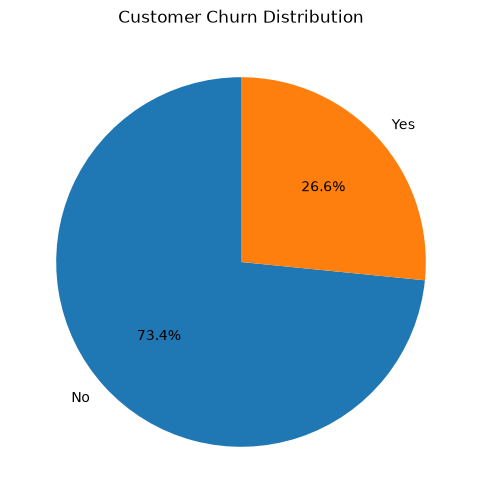

In [6]:
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Distribution")
plt.ylabel("")

plt.show()

### Business Insight

- Approximately **73%** of customers remained with the company.
- Around **27%** of customers churned.
- This indicates that nearly one out of every four customers left the company.
- Reducing churn could significantly improve customer retention and revenue.

### Recommendation

The company should investigate the characteristics of churned customers to identify common patterns and develop targeted retention strategies.

## 3.2 Does Gender Influence Customer Churn?

### Business Question

Is customer churn influenced by gender?

Understanding whether one gender has a higher churn rate helps determine if retention strategies should be gender-specific.

In [7]:
df["gender"].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [8]:
pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [10]:
pd.crosstab(
    df["gender"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


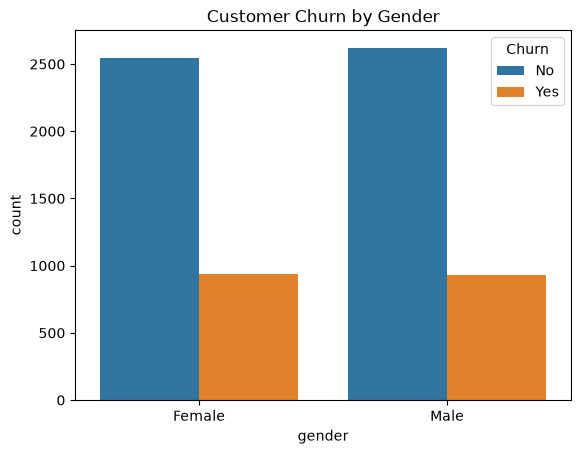

In [11]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.title("Customer Churn by Gender")
plt.show()

### Business Insight

- Male and female customers exhibit very similar churn rates.
- Gender does not appear to have a significant influence on customer churn.
- This suggests that gender is not a strong predictor of churn.

### Recommendation

The company does not need separate retention strategies based on gender.

Instead, it should focus on factors such as:

- Contract Type
- Tenure
- Monthly Charges
- Internet Service
- Payment Method

These are more likely to influence customer churn.

## 3.2 Does Contract Type Influence Customer Churn?

### Business Question

Does the type of customer contract influence the likelihood of churn?

### Business Hypothesis

Customers with **Month-to-Month** contracts are expected to have a higher churn rate than customers with **One-Year** or **Two-Year** contracts. Since they are not bound by long-term commitments, they can easily switch to competitors if they receive better pricing, services, or promotional offers.

In [12]:
contract_counts = df["Contract"].value_counts()

print(contract_counts)

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


### Observation

Before comparing churn, it is important to understand how customers are distributed across the different contract types.

In [13]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"])

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


### Why use Crosstab?

`pd.crosstab()` creates a frequency table that shows how many customers belong to each combination of **Contract Type** and **Churn Status**.

This allows us to compare the number of customers who stayed and churned for each contract type.

In [14]:
# Calculate churn percentage within each contract type
contract_churn_percentage = (
    pd.crosstab(
        df["Contract"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

contract_churn_percentage

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


### Why normalize by index?

Using `normalize="index"` converts the counts into percentages **within each contract type**.

This makes the comparison fair because each contract type contains a different number of customers.

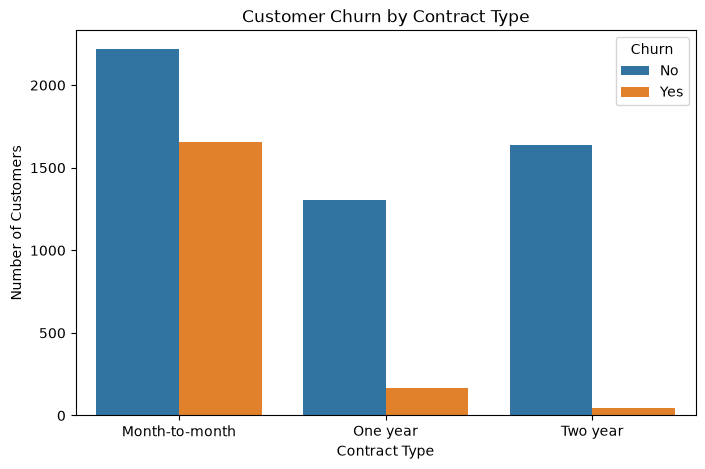

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

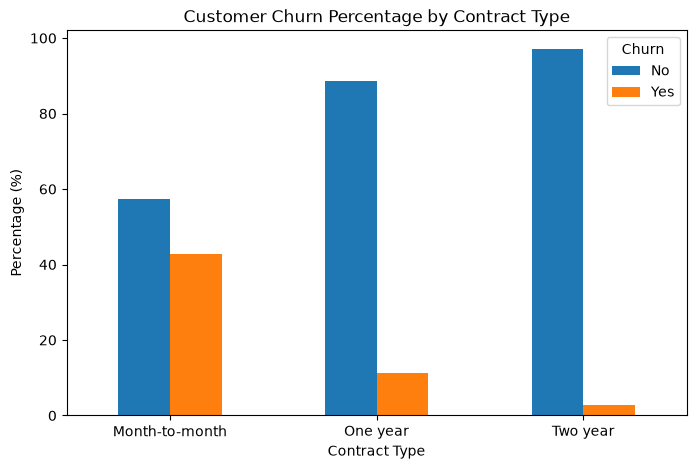

In [16]:
contract_churn_percentage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Percentage by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

## Business Insight

After analyzing the data, the following observations were made:

- Customers with **Month-to-Month** contracts exhibited the highest churn rate.
- Customers with **One-Year** contracts showed a significantly lower churn rate.
- Customers with **Two-Year** contracts had the lowest churn rate among all contract types.
- This suggests that customers who commit to longer contracts are more likely to remain with the company.

## Business Recommendation

To reduce customer churn, the company should:

- Encourage Month-to-Month customers to upgrade to long-term contracts.
- Offer discounts or loyalty rewards for One-Year and Two-Year contracts.
- Introduce exclusive benefits for customers willing to commit to longer subscription periods.
- Target Month-to-Month customers with personalized retention campaigns before they decide to switch providers.

## 3.4 Does Customer Tenure Influence Churn?

### Business Question

Does the length of time a customer has been with the company (tenure) influence their likelihood of churning?

### Business Hypothesis

Customers with shorter tenure are expected to have a higher churn rate because they have not yet developed long-term loyalty or commitment to the company. Customers who have remained with the company for a longer period are expected to be more loyal and therefore less likely to churn.

In [17]:
# Summary statistics of tenure grouped by churn status
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


### Why are we using groupby()?

The `groupby()` function groups customers based on their churn status and calculates descriptive statistics for the tenure of each group.

This helps us compare whether customers who churn have shorter or longer tenures than customers who remain with the company.

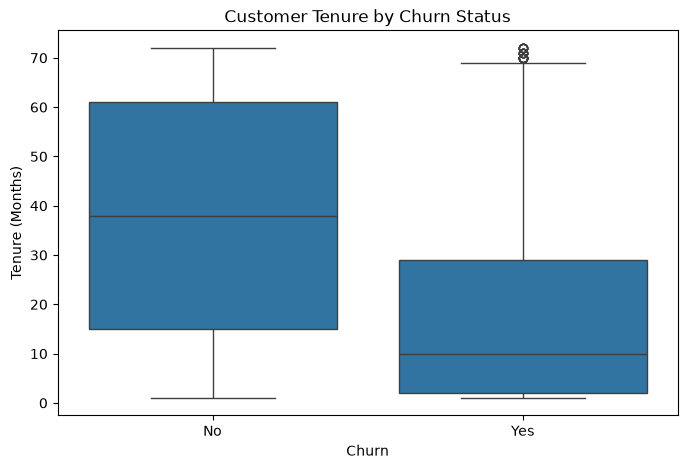

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

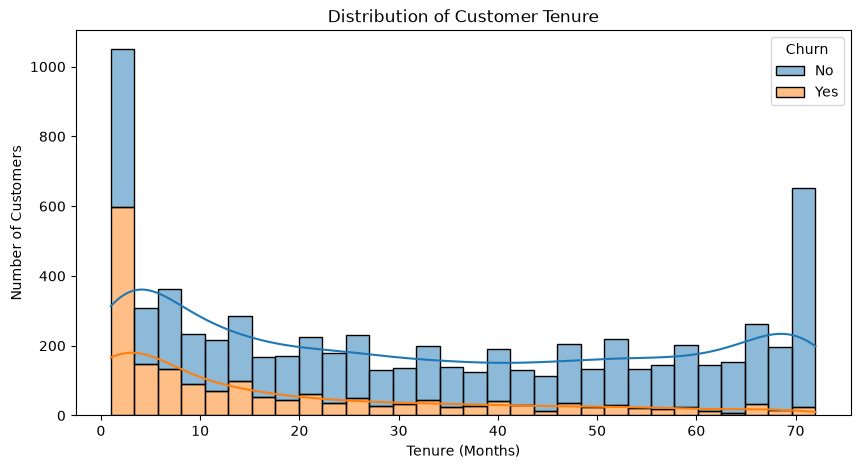

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
# Average tenure by churn status
df.groupby("Churn")["tenure"].mean().round(2)

Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64

## Business Insight

After analyzing customer tenure, the following observations were made:

- Customers who churn generally have a much shorter tenure than customers who stay.
- Long-term customers are significantly less likely to leave the company.
- Customer loyalty appears to increase as tenure increases.
- Tenure is likely to be an important predictor for the machine learning model.

## Business Recommendation

The company should focus on retaining customers during the early months of their relationship.

Recommended strategies include:

- Welcome offers for new customers.
- Personalized onboarding.
- Early customer engagement.
- Loyalty rewards after the first few months.
- Proactive customer support during the initial contract period.

## 3.5 Does Monthly Charges Influence Customer Churn?

### Business Question

Do customers with higher monthly charges have a greater likelihood of churning?

### Business Hypothesis

Customers with higher monthly charges may be more likely to churn because they may perceive the service as expensive or may switch to competitors offering better pricing or value for money.

In [21]:
# Summary statistics of Monthly Charges grouped by churn status

df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


### Why are we using groupby()?

The `groupby()` function groups customers based on their churn status and calculates descriptive statistics for the Monthly Charges of each group.

This allows us to compare whether customers who churn pay more or less on average than customers who stay.

In [22]:
# Average monthly charges by churn status

df.groupby("Churn")["MonthlyCharges"].mean().round(2)

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64

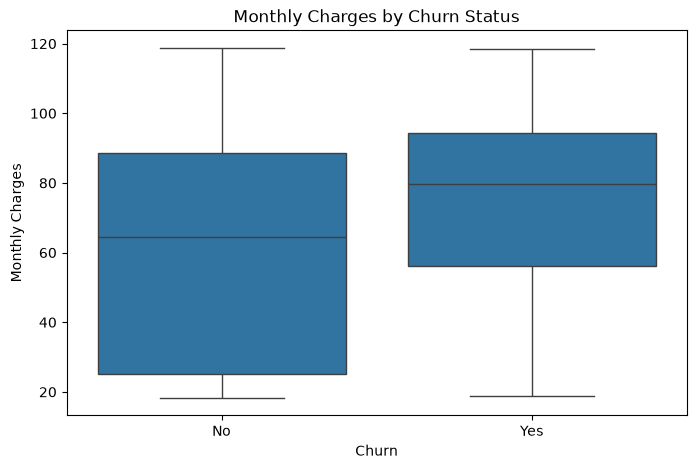

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

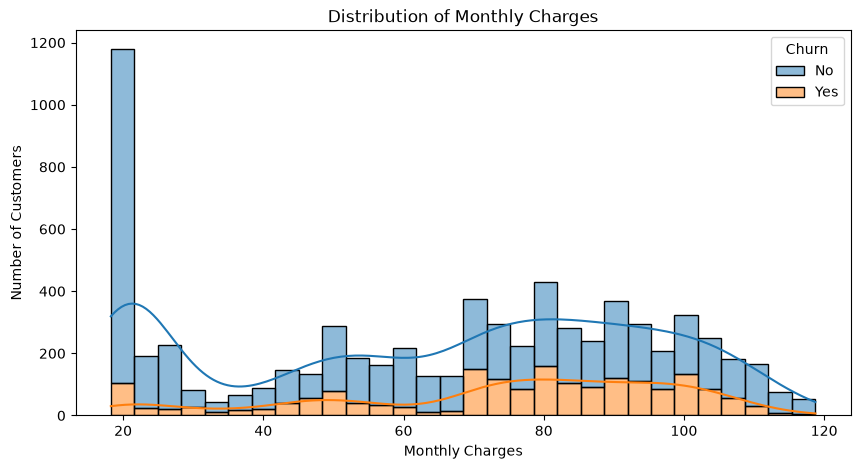

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    hue="Churn",
    bins=30,
    kde=True,
    multiple="stack"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

In [25]:
# Create Monthly Charge groups

df["MonthlyChargeGroup"] = pd.cut(
    df["MonthlyCharges"],
    bins=[0,35,70,100,120],
    labels=["Low","Medium","High","Very High"]
)

In [26]:
# Churn percentage within each Monthly Charge group

monthly_charge_churn = (
    pd.crosstab(
        df["MonthlyChargeGroup"],
        df["Churn"],
        normalize="index"
    )*100
).round(2)

monthly_charge_churn

Churn,No,Yes
MonthlyChargeGroup,,
Low,89.07,10.93
Medium,76.02,23.98
High,62.15,37.85
Very High,71.95,28.05


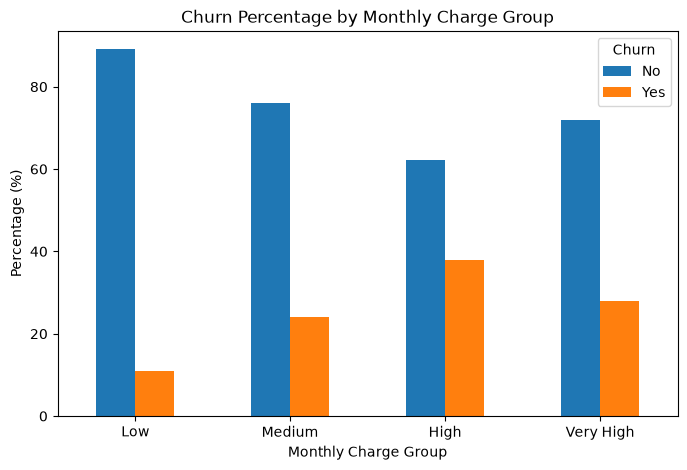

In [27]:
monthly_charge_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Percentage by Monthly Charge Group")
plt.xlabel("Monthly Charge Group")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

## Business Insight

After analyzing Monthly Charges, the following observations were made:

- Customers paying higher monthly charges tend to have a higher churn rate.
- Customers with lower monthly charges generally exhibit better retention.
- Pricing appears to influence customer decisions and may be an important factor in predicting churn.


## Business Recommendation

The company should consider:

- Reviewing pricing strategies for premium plans.
- Offering loyalty discounts to high-paying customers.
- Providing additional benefits or bundled services to increase perceived value.
- Identifying high-value customers who are at risk of churning and targeting them with retention campaigns.

## 3.6 Does Internet Service Influence Customer Churn?

### Business Question

Does the type of internet service subscribed to by a customer influence their likelihood of churning?

### Business Hypothesis

Customers using Fiber Optic internet service may exhibit a higher churn rate than customers using DSL or having no internet service.

Possible reasons include:

- Higher subscription cost
- Greater customer expectations
- Increased competition from alternative providers

In [28]:
# Number of customers by Internet Service

df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

### Observation

Before comparing churn rates, it is important to understand how customers are distributed among the available internet service types.

In [29]:
# Internet Service vs Churn

internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"]
)

internet_churn

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [30]:
# Churn percentage by Internet Service

internet_churn_percentage = (
    pd.crosstab(
        df["InternetService"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

internet_churn_percentage

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


### Why normalize by index?

Each internet service category contains a different number of customers.

Using `normalize="index"` calculates the churn percentage within each service category, allowing a fair comparison.

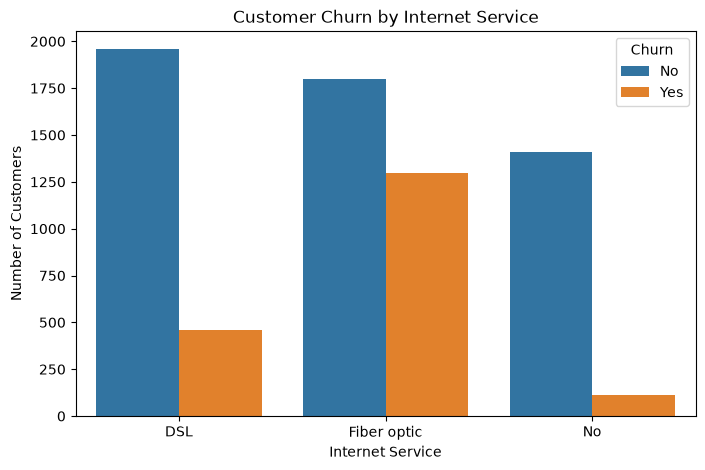

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")

plt.xlabel("Internet Service")

plt.ylabel("Number of Customers")

plt.show()

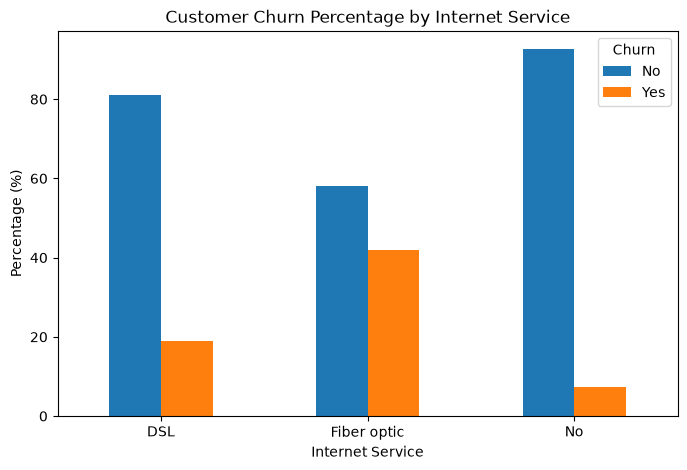

In [32]:
internet_churn_percentage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Percentage by Internet Service")

plt.xlabel("Internet Service")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

## Business Insight

After analyzing Internet Service, the following observations were made:

- Customers using Fiber Optic internet service exhibited the highest churn rate.
- DSL customers demonstrated better customer retention.
- Customers without internet service showed the lowest churn rate.
- Internet Service appears to be an important feature influencing customer churn.

## Business Recommendation

The company should investigate why Fiber Optic customers are leaving.

Possible actions include:

- Improve service quality.
- Review pricing strategies.
- Offer premium customer support.
- Provide loyalty incentives for Fiber Optic customers.

## 3.7 Does Payment Method Influence Customer Churn?

### Business Question

Does the customer's payment method influence the likelihood of churn?

### Business Hypothesis

Customers using **Electronic Check** may exhibit a higher churn rate compared to customers using automatic payment methods such as Bank Transfer or Credit Card.

Automatic payment methods generally improve customer retention by reducing missed payments and increasing customer convenience.

In [33]:
# Number of customers by payment method

payment_method_count = df["PaymentMethod"].value_counts()

payment_method_count

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

### Observation

Before analyzing churn, it is useful to understand how customers are distributed across different payment methods.

In [34]:
# Payment Method vs Churn

payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"]
)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [35]:
# Churn percentage by payment method

payment_churn_percentage = (
    pd.crosstab(
        df["PaymentMethod"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

payment_churn_percentage

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


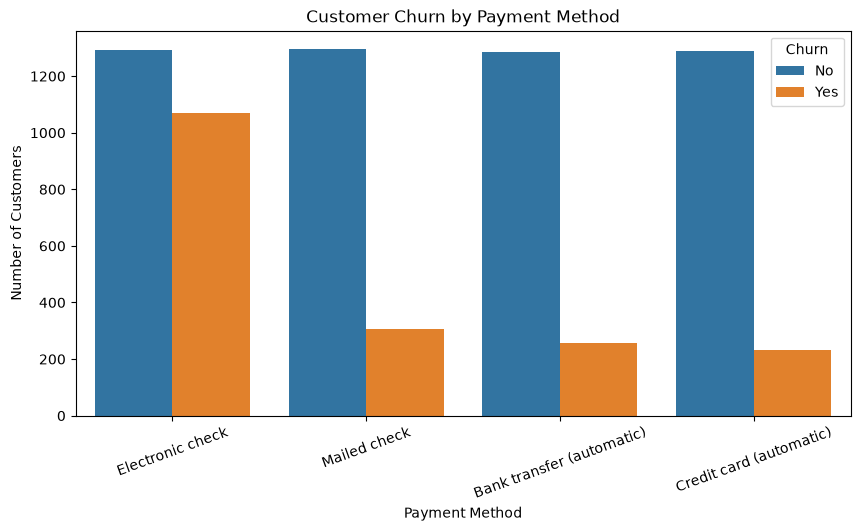

In [36]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.show()

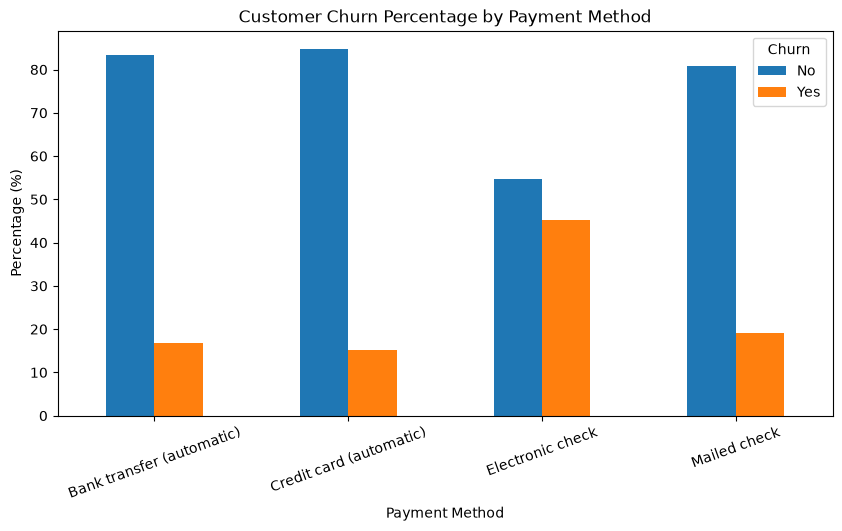

In [37]:
payment_churn_percentage.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Customer Churn Percentage by Payment Method")

plt.xlabel("Payment Method")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=20)

plt.legend(title="Churn")

plt.show()

## Business Insight

After analyzing customer payment methods, the following observations were made:

- Customers using **Electronic Check** exhibited the highest churn rate.
- Customers using automatic payment methods such as **Bank Transfer (Automatic)** and **Credit Card (Automatic)** showed better retention.
- Automatic payment methods appear to improve customer loyalty and reduce churn.

## Business Recommendation

The company should encourage customers to adopt automatic payment methods.

Possible strategies include:

- Cashback for AutoPay enrollment.
- Discount on monthly bills for automatic payments.
- Loyalty rewards for customers using recurring payment methods.
- Promotional campaigns encouraging Electronic Check users to switch to automatic payments.

## 3.8 Does Tech Support Influence Customer Churn?

### Business Question

Does access to technical support influence a customer's likelihood of churning?

### Business Hypothesis

Customers who do not subscribe to Tech Support are expected to have a higher churn rate because unresolved technical issues can reduce customer satisfaction and increase the likelihood of switching to a competitor.

In [38]:
# Number of customers by Tech Support

tech_support_count = df["TechSupport"].value_counts()

tech_support_count

TechSupport
No                     3472
Yes                    2040
No internet service    1520
Name: count, dtype: int64

### Observation

Before analyzing churn, it is important to understand how customers are distributed based on their Tech Support subscription.

In [39]:
# Compare Tech Support with Churn

tech_support_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"]
)

tech_support_churn

Churn,No,Yes
TechSupport,,
No,2026,1446
No internet service,1407,113
Yes,1730,310


In [40]:
# Churn percentage by Tech Support

tech_support_churn_percentage = (
    pd.crosstab(
        df["TechSupport"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

tech_support_churn_percentage

Churn,No,Yes
TechSupport,,
No,58.35,41.65
No internet service,92.57,7.43
Yes,84.80,15.20


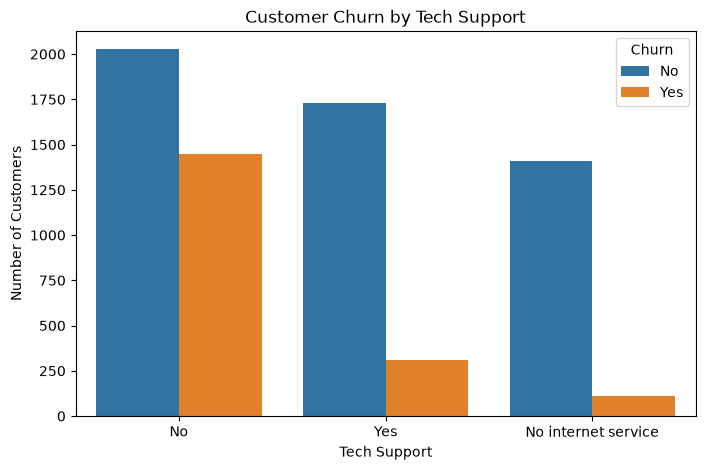

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Customer Churn by Tech Support")

plt.xlabel("Tech Support")

plt.ylabel("Number of Customers")

plt.show()

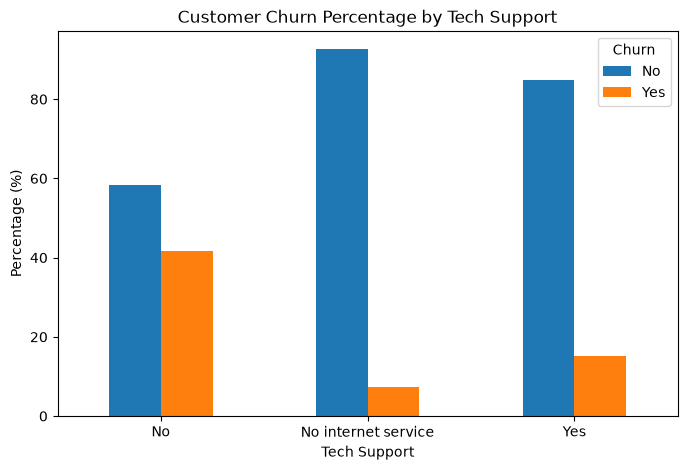

In [42]:
tech_support_churn_percentage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Percentage by Tech Support")

plt.xlabel("Tech Support")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

## Business Insight

The analysis revealed the following:

- Customers without Tech Support exhibited a significantly higher churn rate.
- Customers who subscribed to Tech Support were much more likely to remain with the company.
- Technical support appears to be one of the strongest factors influencing customer retention.

## Business Recommendation

The company should encourage more customers to subscribe to Tech Support services.

Recommended actions include:

- Bundle Tech Support with premium plans.
- Offer free technical support for new customers during the first few months.
- Promote Tech Support benefits through targeted marketing campaigns.
- Prioritize proactive customer support for customers showing signs of dissatisfaction.

## 3.9 Does Online Security Influence Customer Churn?

### Business Question

Does subscribing to Online Security services reduce the likelihood of customer churn?

### Business Hypothesis

Customers who subscribe to Online Security services are expected to have a lower churn rate because the additional security service increases the perceived value of the subscription and strengthens customer loyalty.

In [43]:
# Distribution of Online Security subscriptions

online_security_count = df["OnlineSecurity"].value_counts()

online_security_count

OnlineSecurity
No                     3497
Yes                    2015
No internet service    1520
Name: count, dtype: int64

### Observation

Understanding the distribution of customers with and without Online Security provides context before analyzing churn behavior.

In [44]:
# Online Security vs Churn

online_security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"]
)

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,2036,1461
No internet service,1407,113
Yes,1720,295


In [45]:
# Churn percentage by Online Security

online_security_percentage = (
    pd.crosstab(
        df["OnlineSecurity"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

online_security_percentage

Churn,No,Yes
OnlineSecurity,,
No,58.22,41.78
No internet service,92.57,7.43
Yes,85.36,14.64


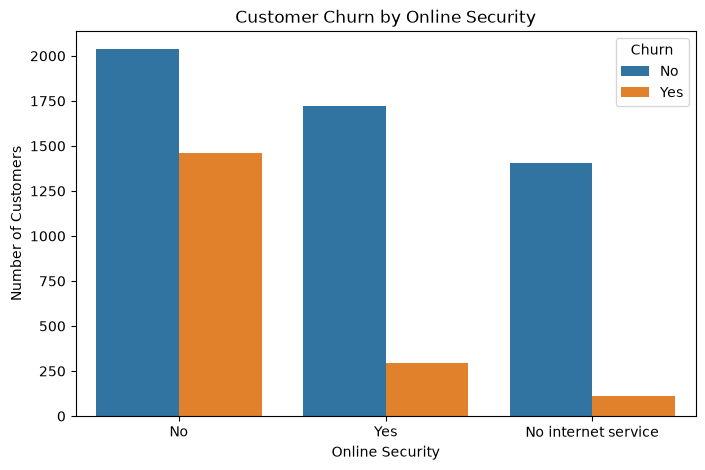

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Customer Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Number of Customers")

plt.show()

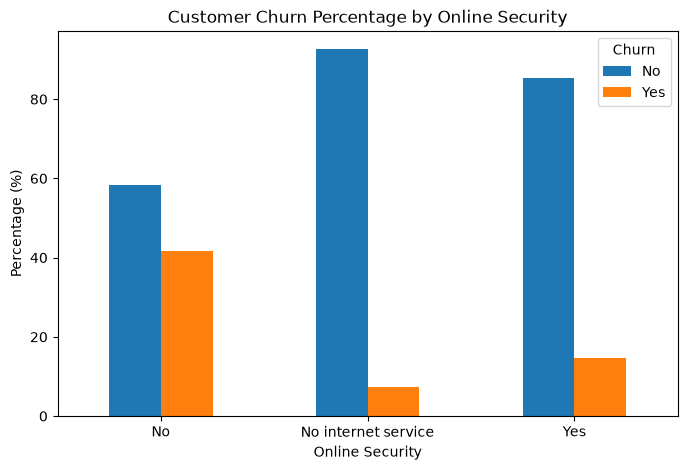

In [47]:
online_security_percentage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Percentage by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

## Business Insight

The analysis revealed the following:

- Customers without Online Security services exhibited a significantly higher churn rate.
- Customers subscribed to Online Security demonstrated stronger customer retention.
- Online Security appears to be an important value-added service contributing to customer loyalty.

## Business Recommendation

To improve customer retention, the company should:

- Bundle Online Security with popular internet plans.
- Offer free Online Security trials for new customers.
- Provide promotional discounts for customers upgrading to security-enabled plans.
- Highlight the benefits of Online Security during customer onboarding and renewal campaigns.

## 3.10 Does Senior Citizen Status Influence Customer Churn?

### Business Question

Does being a senior citizen influence the likelihood of customer churn?

### Business Hypothesis

Senior citizens may have different service expectations, support requirements, and pricing sensitivity. These factors may influence their likelihood of leaving the company.

In [49]:
# Number of customers by Senior Citizen status

df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64

### Observation

The `SeniorCitizen` column is encoded as:

- **0** → Not a Senior Citizen
- **1** → Senior Citizen

Before analyzing churn, we first observe how customers are distributed between these two groups.

In [50]:
# Compare Senior Citizen with Churn

senior_churn = pd.crosstab(
    df["SeniorCitizen"],
    df["Churn"]
)

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,4497,1393
1,666,476


In [51]:
# Churn percentage by Senior Citizen

senior_churn_percentage = (
    pd.crosstab(
        df["SeniorCitizen"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

senior_churn_percentage

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


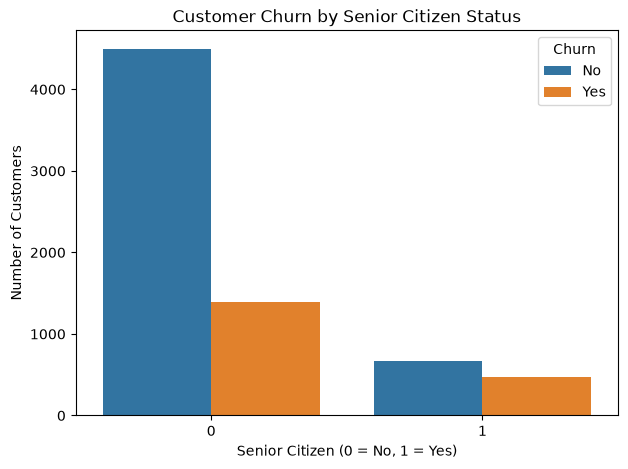

In [52]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")

plt.show()

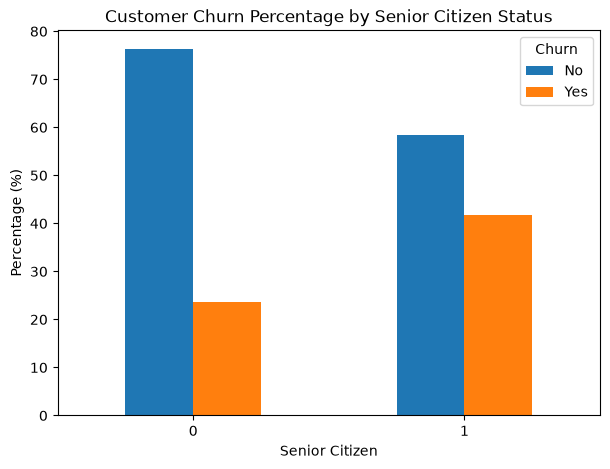

In [53]:
senior_churn_percentage.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Customer Churn Percentage by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

## Business Insight

The analysis showed that:

- Senior citizens exhibit a higher churn rate compared to non-senior customers.
- Senior citizens may require additional support and personalized services.
- Customer age appears to influence retention and should be considered in predictive modeling.

## Business Recommendation

To improve retention among senior citizens, the company should:

- Provide dedicated customer support.
- Simplify service plans and billing.
- Offer senior citizen discounts.
- Conduct regular customer satisfaction surveys.

## 3.11 Correlation Analysis

### Business Question

Are there strong relationships between the numerical features in the dataset?

### Business Objective

Correlation analysis helps identify relationships between numerical variables. Understanding these relationships can provide valuable business insights and help during feature selection for machine learning models.

**Note:** Correlation measures the strength of a linear relationship between numerical variables. It does not imply causation.

In [54]:
# Select numerical columns

numerical_columns = df.select_dtypes(include=["int64", "float64"])

numerical_columns.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


### Why use `select_dtypes()`?

The dataset contains both numerical and categorical variables.

Since correlation calculations require numerical values, we first select only the integer and floating-point columns.

In [55]:
# Display numerical column names

numerical_columns.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [56]:
# Calculate correlation matrix

correlation_matrix = numerical_columns.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


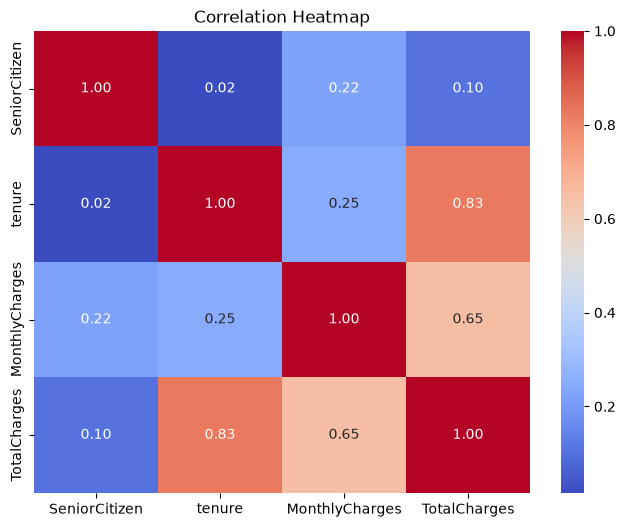

In [57]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Business Insight

The correlation analysis shows the strength of relationships among numerical variables.

Key observations include:

- Total Charges and Tenure are expected to exhibit a strong positive correlation because customers who stay longer generally accumulate higher total charges.
- Monthly Charges and Total Charges may also show a positive relationship.
- Senior Citizen is expected to have a weak correlation with the other numerical variables.

## Important Note

Correlation analysis is limited to numerical variables.

Most of the important features in this dataset (such as Contract Type, Internet Service, Tech Support, and Payment Method) are categorical.

These relationships will be captured later by the machine learning model after appropriate feature encoding.

# 3.12 Executive Summary

## Key Business Insights

The exploratory data analysis identified several important factors that influence customer churn. The following table summarizes the major findings and recommended business actions.

In [58]:


summary = pd.DataFrame({
    "Business Question": [
        "Overall Churn",
        "Gender",
        "Contract Type",
        "Tenure",
        "Monthly Charges",
        "Internet Service",
        "Payment Method",
        "Tech Support",
        "Online Security",
        "Senior Citizen"
    ],

    "Key Finding": [
        "Approximately 27% of customers churned.",
        "Gender has minimal influence on churn.",
        "Month-to-Month customers exhibit the highest churn.",
        "Customers with shorter tenure churn more frequently.",
        "Higher monthly charges are associated with higher churn.",
        "Fiber Optic customers have the highest churn.",
        "Electronic Check customers churn more frequently.",
        "Customers without Tech Support churn significantly more.",
        "Customers without Online Security churn significantly more.",
        "Senior citizens exhibit a higher churn rate."
    ],

    "Business Impact": [
        "High",
        "Low",
        "High",
        "High",
        "Medium",
        "High",
        "Medium",
        "High",
        "High",
        "Medium"
    ],

    "Recommendation": [
        "Develop customer retention strategies.",
        "No gender-specific campaigns required.",
        "Promote long-term contracts.",
        "Improve onboarding and early customer engagement.",
        "Review premium pricing and offer loyalty discounts.",
        "Improve Fiber Optic service quality.",
        "Encourage customers to adopt AutoPay.",
        "Bundle Tech Support with service plans.",
        "Offer Online Security promotions.",
        "Provide dedicated support for senior citizens."
    ]
})

summary.style.hide(axis="index")

Business Question,Key Finding,Business Impact,Recommendation
Overall Churn,Approximately 27% of customers churned.,High,Develop customer retention strategies.
Gender,Gender has minimal influence on churn.,Low,No gender-specific campaigns required.
Contract Type,Month-to-Month customers exhibit the highest churn.,High,Promote long-term contracts.
Tenure,Customers with shorter tenure churn more frequently.,High,Improve onboarding and early customer engagement.
Monthly Charges,Higher monthly charges are associated with higher churn.,Medium,Review premium pricing and offer loyalty discounts.
Internet Service,Fiber Optic customers have the highest churn.,High,Improve Fiber Optic service quality.
Payment Method,Electronic Check customers churn more frequently.,Medium,Encourage customers to adopt AutoPay.
Tech Support,Customers without Tech Support churn significantly more.,High,Bundle Tech Support with service plans.
Online Security,Customers without Online Security churn significantly more.,High,Offer Online Security promotions.
Senior Citizen,Senior citizens exhibit a higher churn rate.,Medium,Provide dedicated support for senior citizens.


## Overall Conclusion

The exploratory data analysis indicates that customer churn is primarily influenced by service-related and contract-related factors rather than demographic characteristics.

The most influential business factors include:

- Contract Type
- Customer Tenure
- Monthly Charges
- Internet Service
- Tech Support
- Online Security

These insights will guide feature engineering and machine learning model development in the next phase of the project.